# 05 — Fama-French 5-Factor + Momentum Alpha

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import yfinance as yf
import statsmodels.api as sm

BASE = Path(os.getcwd())

RF_ANNUAL  = 0.065          # RBI repo-rate proxy
RF_MONTHLY = RF_ANNUAL / 12
RF_DAILY   = RF_ANNUAL / 252

# FY windows (Apr–Mar)
FY_WINDOWS = {
    'FY23': ('2022-04-01', '2023-03-31'),
    'FY24': ('2023-04-01', '2024-03-31'),
    'FY25': ('2024-04-01', '2025-03-31'),
}

# Q4 filing FYs (annual CG report → 252 td window forward)
Q4_FYS = ['Q4FY22', 'Q4FY23', 'Q4FY24']

# Factor portfolio breakpoints (30/40/30 split for B/M, OP, Inv)
Q_LO, Q_HI = 0.30, 0.70

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Parameters set.')

In [4]:
imap = pd.read_excel(BASE / 'data' / 'industry_map.xlsx')
imap = imap.dropna(subset=['NSE Symbol']).copy()
imap['BSE Code'] = pd.to_numeric(imap['BSE Code'], errors='coerce').astype('Int64')
tickers_ns = [f"{s}.NS" for s in imap['NSE Symbol']]
print(f'Companies: {len(tickers_ns)}')


fdb = pd.read_csv(BASE / 'data' / 'filing_dates_db.csv')
fdb['BSE_Code']    = pd.to_numeric(fdb['BSE_Code'], errors='coerce').astype('Int64')
fdb['Filing_Date'] = pd.to_datetime(fdb['Filing_Date'])

q4_filings = (
    fdb[fdb['Q_FY'].isin(Q4_FYS)]
    [['BSE_Code','Q_FY','Filing_Date']]
    .merge(imap[['BSE Code','NSE Symbol']], left_on='BSE_Code', right_on='BSE Code', how='inner')
    .drop(columns='BSE Code')
    .reset_index(drop=True)
)
q4_filings['FY'] = 'FY' + q4_filings['Q_FY'].str[-2:]

print(f'Q4 filings loaded: {len(q4_filings)} rows')
print(q4_filings.groupby('Q_FY')['NSE Symbol'].count().to_string())

Companies: 247
Q4 filings loaded: 711 rows
Q_FY
Q4FY22    217
Q4FY23    247
Q4FY24    247


In [5]:
# Start July 2019 — gives enough history for 12-month momentum lookback

print('Downloading Nifty 500 index...')
mkt_raw = yf.download('^CRSLDX', start='2019-07-01', end='2026-05-01',
                      auto_adjust=True, progress=False)['Close'].squeeze()
print(f'  Market: {len(mkt_raw)} trading days')

print('Downloading stock daily prices (batch)...')
px_raw = yf.download(tickers_ns, start='2019-07-01', end='2026-05-01',
                     auto_adjust=True, progress=True)['Close']

# Drop tickers with >50% missing
valid = px_raw.columns[px_raw.isna().mean() < 0.5].tolist()
px = px_raw[valid]

print(f'Valid tickers: {len(valid)} / {len(tickers_ns)}')
print(f'Date range: {px.index[0].date()} → {px.index[-1].date()}')


px_m   = px.resample('ME').last()
mkt_m  = mkt_raw.resample('ME').last()


ret_m   = np.log(px_m / px_m.shift(1)).dropna(how='all')   # log returns
mkt_rm  = np.log(mkt_m / mkt_m.shift(1)).dropna()


ret_d   = np.log(px / px.shift(1)).dropna(how='all')
mkt_rd  = np.log(mkt_raw / mkt_raw.shift(1)).dropna()

# Trading-day count per calendar month (for daily factor distribution)
td_per_month = ret_d.resample('ME').count().iloc[:, 0].rename('n_td')

print('Monthly returns shape:', ret_m.shape)
print('Daily returns shape  :', ret_d.shape)

  Market: 1663 trading days


[****                   8%                       ]  20 of 247 completed$ZOMATO.NS: possibly delisted; no timezone found
[*****************     36%                       ]  89 of 247 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PEL.NS"}}}
[*****************     36%                       ]  90 of 247 completed$PEL.NS: possibly delisted; no timezone found
[**********************51%                       ]  127 of 247 completed$SUVENPHARMA.NS: possibly delisted; no timezone found
[**********************66%*******                ]  164 of 247 completed$GET&D.NS: possibly delisted; no timezone found
[**********************80%*************          ]  198 of 247 completed$ISEC.NS: possibly delisted; no timezone found
[*********************100%***********************]  247 of 247 completed

5 Failed downloads:
['ZOMATO.NS', 'PEL.NS', 'SUVENPHARMA.NS', 'GET&D.NS', 'ISEC.NS']: possibly delisted; no timezone found


Valid tickers: 231 / 247
Date range: 2019-07-01 → 2026-04-07
Monthly returns shape: (81, 231)
Daily returns shape  : (1672, 231)


In [6]:
BS_EQUITY = ['Common Stock Equity', 'Stockholders Equity',
             'Total Equity Gross Minority Interest']
BS_ASSETS = ['Total Assets']
BS_SHARES = ['Ordinary Shares Number', 'Share Issued']
IS_GP     = ['Gross Profit']
IS_INT    = ['Interest Expense', 'Interest Expense Non Operating']

def _first(df, rows):
    """Return first matching row's series, or None."""
    for r in rows:
        if r in df.index:
            return df.loc[r]
    return None

fund = {} 
failed = []

for i, ticker in enumerate(valid):
    try:
        t  = yf.Ticker(ticker)
        bs = t.balance_sheet
        ic = t.income_stmt
        if bs is None or bs.empty:
            failed.append(ticker); continue
        # Normalise column dtypes
        bs.columns = pd.to_datetime(bs.columns)
        ic.columns = pd.to_datetime(ic.columns)
        fund[ticker] = {'bs': bs, 'ic': ic}
    except Exception:
        failed.append(ticker)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(valid)} done …'); time.sleep(1)

print(f'\nFundamental data loaded: {len(fund)} tickers, {len(failed)} failed')
# Sample date coverage
sample = next(iter(fund.values()))['bs']
print(f'Sample balance-sheet dates: {[str(d.date()) for d in sample.columns]}')

  50/231 done …
  100/231 done …
  150/231 done …
  200/231 done …

Fundamental data loaded: 231 tickers, 0 failed
Sample balance-sheet dates: ['2025-03-31', '2024-03-31', '2023-03-31', '2022-03-31']


In [7]:
FORMATION_YEARS = [2022, 2023, 2024, 2025]  # July 2022–2025

def build_sort_vars(formation_year):
    """
    At end of June {formation_year}, build sorting variables
    using FY balance sheet (March {formation_year}).
    Returns DataFrame: ticker, me, be, bm, op, inv.
    """
    june_end = pd.Timestamp(f'{formation_year}-06-30')
    # Price at June end
    px_june = px_m.loc[px_m.index <= june_end].iloc[-1]

    rows = []
    for ticker, fd in fund.items():
        bs, ic = fd['bs'], fd['ic']
        # Most recent BS date on or before June end
        bs_dates = bs.columns[bs.columns <= june_end]
        if bs_dates.empty: continue
        bd = bs_dates.max()   # latest available before June (yfinance returns descending order)

        # Prior year BS date (for investment)
        prev_dates = bs.columns[bs.columns < bd]
        bd_prev = prev_dates.max() if not prev_dates.empty else None

        # Extract balance sheet items
        be_s  = _first(bs, BS_EQUITY)
        ta_s  = _first(bs, BS_ASSETS)
        sh_s  = _first(bs, BS_SHARES)

        if be_s is None or sh_s is None: continue
        be     = pd.to_numeric(be_s.get(bd),   errors='coerce')
        ta_now = pd.to_numeric(ta_s.get(bd),   errors='coerce') if ta_s is not None else np.nan
        shares = pd.to_numeric(sh_s.get(bd),   errors='coerce')

        if pd.isna(be) or be <= 0 or pd.isna(shares) or shares <= 0: continue

        price  = px_june.get(ticker, np.nan)
        if pd.isna(price) or price <= 0: continue

        me = price * shares
        bm = be / me

        # Investment: (TA_t - TA_{t-1}) / TA_{t-1}
        inv = np.nan
        if bd_prev is not None and ta_s is not None:
            ta_prev = pd.to_numeric(ta_s.get(bd_prev), errors='coerce')
            if pd.notna(ta_prev) and ta_prev > 0:
                inv = (ta_now - ta_prev) / ta_prev

        # Operating profitability: (Gross Profit - Interest) / BE
        ic_dates = ic.columns[ic.columns <= june_end]
        op = np.nan
        if not ic_dates.empty:
            id_ = ic_dates.max()
            gp_s  = _first(ic, IS_GP)
            int_s = _first(ic, IS_INT)
            gp  = pd.to_numeric(gp_s.get(id_),  errors='coerce') if gp_s is not None else np.nan
            int_e = pd.to_numeric(int_s.get(id_), errors='coerce') if int_s is not None else 0.0
            if pd.notna(gp):
                op = (gp - (int_e if pd.notna(int_e) else 0)) / be

        rows.append({'ticker': ticker, 'me': me, 'be': be,
                     'bm': bm, 'op': op, 'inv': inv})

    df = pd.DataFrame(rows)
    # Winsorize bm, op, inv at 1%/99% to remove data errors
    for col in ['bm', 'op', 'inv']:
        lo, hi = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(lo, hi)
    return df

sort_vars = {yr: build_sort_vars(yr) for yr in FORMATION_YEARS}

for yr, sv in sort_vars.items():
    print(f'Formation {yr}: {len(sv)} stocks  '
          f'| ME median: {sv.me.median()/1e9:.1f}B  '
          f'| BM median: {sv.bm.median():.3f}  '
          f'| OP valid: {sv.op.notna().sum()}  '
          f'| Inv valid: {sv.inv.notna().sum()}')

Formation 2022: 221 stocks  | ME median: 196.2B  | BM median: 0.254  | OP valid: 194  | Inv valid: 1
Formation 2023: 228 stocks  | ME median: 252.9B  | BM median: 0.233  | OP valid: 201  | Inv valid: 222
Formation 2024: 229 stocks  | ME median: 364.6B  | BM median: 0.164  | OP valid: 202  | Inv valid: 229
Formation 2025: 229 stocks  | ME median: 388.1B  | BM median: 0.185  | OP valid: 202  | Inv valid: 229


In [8]:
# FF5 methodology (Fama & French 2015):
#   Size: median split → S (small), B (big)
#   B/M, OP, Inv: 30/40/30 quantile split → L/M/H (or W/N/R, A/N/C)
#   Three 2×3 intersections → three SMB components + HML, RMW, CMA
#   MOM: monthly sort, prior 12-2 month return, top/bottom 30%

def assign_groups(df):
    """Add size_grp (S/B) and bm_grp / op_grp / inv_grp (L/M/H) columns."""
    d = df.copy()
    # Size: median split
    me_med = d['me'].median()
    d['sz'] = np.where(d['me'] <= me_med, 'S', 'B')
    # B/M, OP, Inv: 30/40/30
    for col, grp_col in [('bm','bg'), ('op','og'), ('inv','ig')]:
        valid_mask = d[col].notna()
        d[grp_col] = None
        if valid_mask.sum() >= 10:
            lo = d.loc[valid_mask, col].quantile(Q_LO)
            hi = d.loc[valid_mask, col].quantile(Q_HI)
            d.loc[valid_mask, grp_col] = pd.cut(
                d.loc[valid_mask, col], bins=[-np.inf, lo, hi, np.inf],
                labels=['L','M','H'])
    return d

def vw_ret(tickers, me_weights, month_ret):
    """Value-weighted return for a set of tickers."""
    r = month_ret.reindex(tickers).dropna()
    w = pd.Series(me_weights, index=tickers).reindex(r.index)
    if w.sum() == 0: return np.nan
    return (r * w).sum() / w.sum()

def smb_hml_rmw_cma(grp_df, month_ret):
    """Compute SMB, HML, RMW, CMA from a grouped DataFrame."""
    results = {}
    # B/M sort: 2×3 → HML and SMB_bm
    for grp_col, label in [('bg','bm'), ('og','op'), ('ig','inv')]:
        if grp_col not in grp_df.columns: continue
        vals = {}
        for sz in ['S','B']:
            for g in ['L','M','H']:
                subset = grp_df[(grp_df['sz']==sz) & (grp_df[grp_col]==g)]
                if len(subset) < 2: vals[(sz,g)] = np.nan; continue
                vals[(sz,g)] = vw_ret(subset['ticker'].tolist(),
                                      subset['me'].tolist(), month_ret)
        sh = np.nanmean([vals.get(('S','H'), np.nan), vals.get(('B','H'), np.nan)])
        sl = np.nanmean([vals.get(('S','L'), np.nan), vals.get(('B','L'), np.nan)])
        ss = np.nanmean([vals.get(('S','L'), np.nan), vals.get(('S','M'), np.nan),
                          vals.get(('S','H'), np.nan)])
        bs = np.nanmean([vals.get(('B','L'), np.nan), vals.get(('B','M'), np.nan),
                          vals.get(('B','H'), np.nan)])
        results[label+'_HL'] = sh - sl   # HML / RMW / CMA before sign flip
        results[label+'_SMB'] = ss - bs

    # HML = bm_HL, RMW = op_HL, CMA = -inv_HL (conservative - aggressive)
    HML = results.get('bm_HL', np.nan)
    RMW = results.get('op_HL', np.nan)
    CMA = -results.get('inv_HL', np.nan)  # low inv = conservative = high CMA
    SMB = np.nanmean([results.get('bm_SMB', np.nan),
                      results.get('op_SMB', np.nan),
                      results.get('inv_SMB', np.nan)])
    return SMB, HML, RMW, CMA


# Portfolio assignments change each July
current_grp = None
factor_records = []

for month in ret_m.index:
    yr = month.year
    mo = month.month

    # Refresh annual portfolios each July
    if mo == 7:
        form_yr = yr  # July yr → uses March yr balance sheet
        if form_yr in sort_vars and not sort_vars[form_yr].empty:
            current_grp = assign_groups(sort_vars[form_yr])
        elif form_yr - 1 in sort_vars and not sort_vars[form_yr-1].empty:
            # Carry forward previous year if current not available
            current_grp = assign_groups(sort_vars[form_yr - 1])

    if current_grp is None:
        continue

    month_ret = ret_m.loc[month].dropna()
    if len(month_ret) < 20:
        continue


    mkt = mkt_rm.get(month, np.nan)
    if pd.isna(mkt): continue
    mkt_rf = mkt - RF_MONTHLY


    SMB, HML, RMW, CMA = smb_hml_rmw_cma(current_grp, month_ret)


    try:
        m12 = ret_m.loc[:month].iloc[-13]  # t-12
        m2  = ret_m.loc[:month].iloc[-2]   # t-2 (skip last month)
        # Cumulative log return t-12 to t-2
        lookback_slice = ret_m.loc[m12.name:m2.name]
        mom_ret = lookback_slice.sum()
        mom_ret = mom_ret[mom_ret.notna() & (mom_ret != 0)]
        if len(mom_ret) < 20:
            MOM = np.nan
        else:
            lo_m = mom_ret.quantile(Q_LO)
            hi_m = mom_ret.quantile(Q_HI)
            winners = mom_ret[mom_ret >= hi_m].index.intersection(month_ret.index)
            losers  = mom_ret[mom_ret <= lo_m].index.intersection(month_ret.index)
            win_grp = current_grp[current_grp['ticker'].isin(winners)]
            los_grp = current_grp[current_grp['ticker'].isin(losers)]
            r_win = vw_ret(win_grp['ticker'].tolist(), win_grp['me'].tolist(), month_ret)
            r_los = vw_ret(los_grp['ticker'].tolist(), los_grp['me'].tolist(), month_ret)
            MOM = r_win - r_los
    except Exception:
        MOM = np.nan

    factor_records.append({
        'Date': month,
        'Mkt_RF': mkt_rf, 'SMB': SMB, 'HML': HML,
        'RMW': RMW, 'CMA': CMA, 'MOM': MOM,
    })

factors_m = pd.DataFrame(factor_records).set_index('Date').dropna(how='all')

out_f = BASE / 'data' / 'ff5mom_factors_monthly.csv'
factors_m.to_csv(out_f)
print(f'Factors: {factors_m.shape}  ({factors_m.index[0].date()} → {factors_m.index[-1].date()})')
print(factors_m.describe().round(4).to_string())

Factors: (46, 6)  (2022-07-31 → 2026-04-30)
        Mkt_RF      SMB      HML      RMW      CMA      MOM
count  46.0000  46.0000  46.0000  46.0000  34.0000  46.0000
mean    0.0046   0.0095   0.0148  -0.0009   0.0012  -0.0055
std     0.0423   0.0312   0.0336   0.0226   0.0230   0.0415
min    -0.1263  -0.0758  -0.0385  -0.0504  -0.0555  -0.1529
25%    -0.0238  -0.0103  -0.0088  -0.0189  -0.0039  -0.0231
50%     0.0078   0.0112   0.0086  -0.0023   0.0034  -0.0078
75%     0.0318   0.0341   0.0354   0.0158   0.0114   0.0240
max     0.0858   0.0737   0.1232   0.0416   0.0463   0.0732


=== Monthly Factor Summary (annualised %) ===
        Mean_ann%  t-stat  Std_m%
Mkt_RF       5.48    0.73    4.23
SMB         11.44    2.07    3.12
HML         17.80    2.99    3.36
RMW         -1.02   -0.26    2.26
CMA          1.47    0.36    2.30
MOM         -6.65   -0.91    4.15

=== Factor Correlation Matrix ===
        Mkt_RF    SMB    HML    RMW    CMA    MOM
Mkt_RF   1.000  0.141  0.072 -0.323  0.142  0.263
SMB      0.141  1.000  0.043  0.088  0.227  0.170
HML      0.072  0.043  1.000 -0.470  0.242 -0.106
RMW     -0.323  0.088 -0.470  1.000 -0.381 -0.082
CMA      0.142  0.227  0.242 -0.381  1.000  0.022
MOM      0.263  0.170 -0.106 -0.082  0.022  1.000


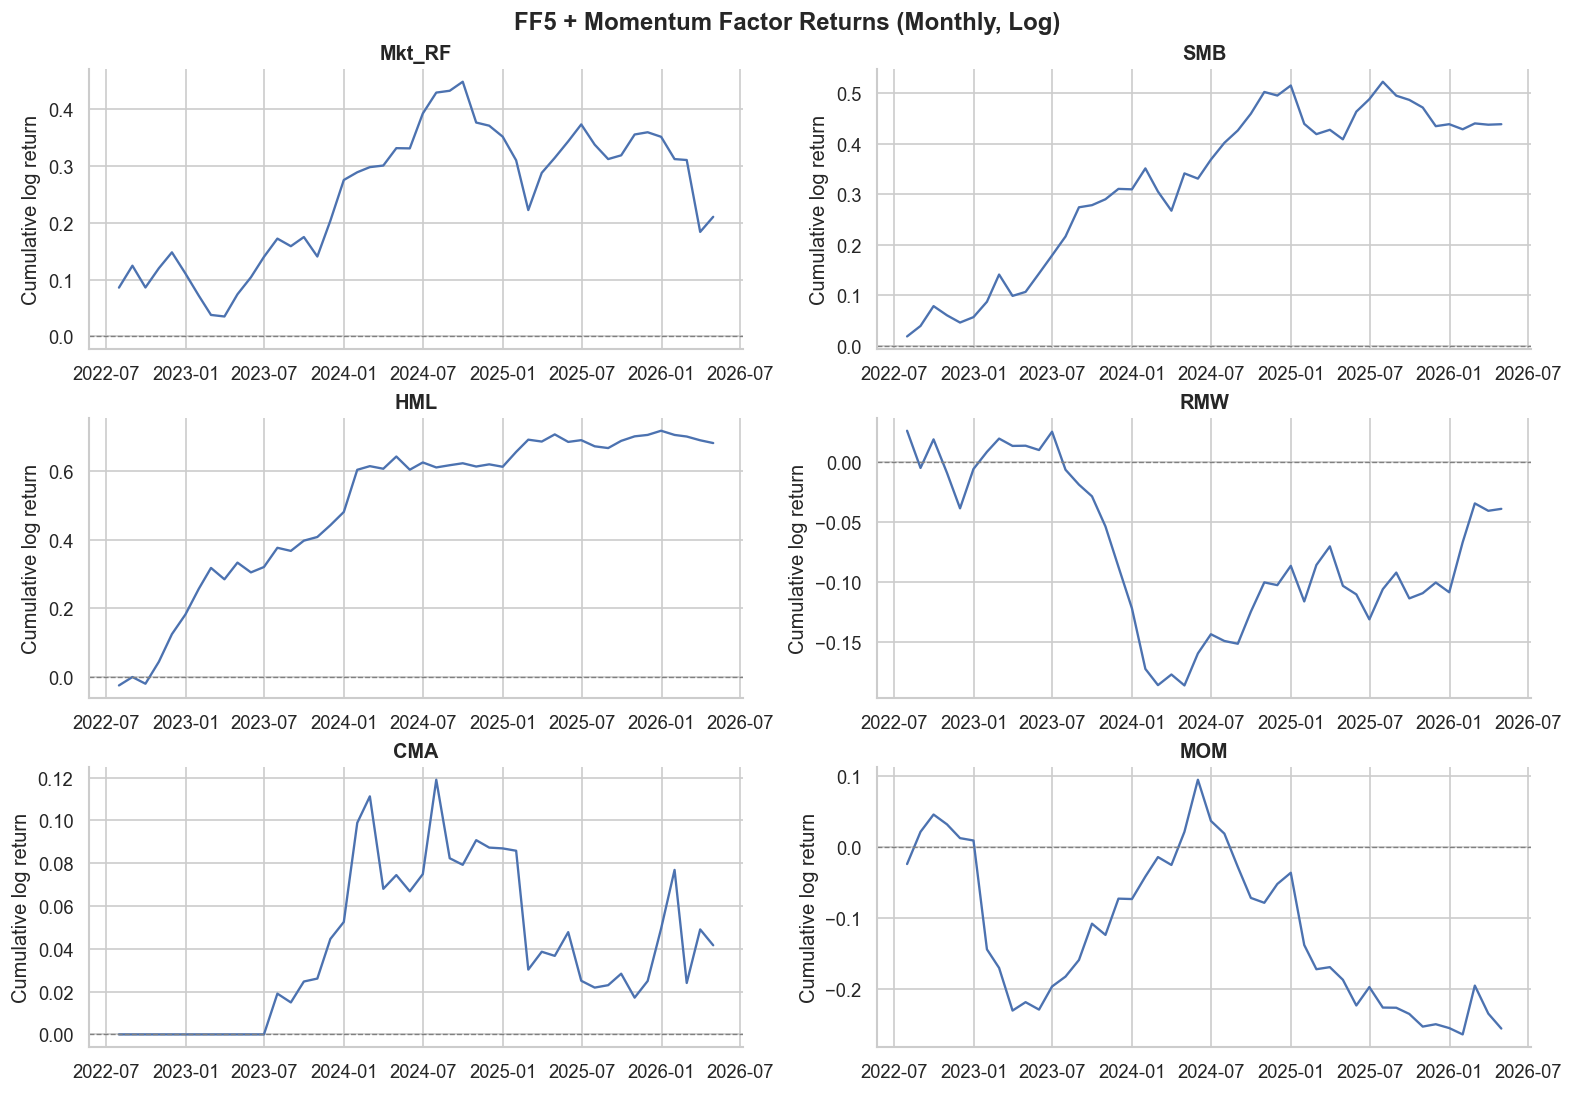

In [9]:
print('=== Monthly Factor Summary (annualised %) ===')
ann = factors_m.mean() * 12 * 100
tval = (factors_m.mean() / (factors_m.std() / np.sqrt(len(factors_m)))) 
summary = pd.DataFrame({'Mean_ann%': ann.round(2),
                         't-stat': tval.round(2),
                         'Std_m%': (factors_m.std()*100).round(2)})
print(summary.to_string())

print('\n=== Factor Correlation Matrix ===')
print(factors_m.corr().round(3).to_string())


fig, axes = plt.subplots(3, 2, figsize=(13, 9), constrained_layout=True)
fig.suptitle('FF5 + Momentum Factor Returns (Monthly, Log)', fontweight='bold')
for ax, col in zip(axes.flat, factors_m.columns):
    cumret = factors_m[col].fillna(0).cumsum()
    ax.plot(cumret.index, cumret, lw=1.4)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Cumulative log return')
    ax.spines[['top','right']].set_visible(False)
plt.show()

In [10]:
FACTOR_COLS = ['Mkt_RF','SMB','HML','RMW','CMA','MOM']

fac_m = factors_m.copy()
fac_m.index = fac_m.index.year * 100 + fac_m.index.month   # e.g. 202207

# Map each trading day to its YYYYMM key
daily_key = ret_d.index.year * 100 + ret_d.index.month      # int array, length=n_days

# Trading days per month (for equal daily distribution)
td_per_month = pd.Series(1, index=daily_key).groupby(level=0).sum()

# Vectorised reindex: each day gets its month's factor row / n_td
fac_for_day = fac_m.reindex(daily_key)                                 # (n_days × 6)
td_for_day  = td_per_month.reindex(daily_key).fillna(21).values        # (n_days,)

factors_d = pd.DataFrame(
    fac_for_day.values / td_for_day[:, None],
    index=ret_d.index,
    columns=FACTOR_COLS
)


factors_d['CMA'] = factors_d['CMA'].fillna(0)


print(f'Daily factors shape : {factors_d.shape}')
print(f'\nNaN count per column:')
print(factors_d.isna().sum().to_string())
print(f'\nNaN count per column in FY24 (2023-04 → 2024-03):')
fy24 = factors_d.loc['2023-04-01':'2024-03-31']
print(fy24.isna().sum().to_string())
print(f'\nfactors_d dtypes:')
print(factors_d.dtypes.to_string())
# Sanity: daily Mkt_RF sum over FY24 should ≈ monthly sum
print(f'\nMkt_RF sum FY24 (daily)  : {fy24["Mkt_RF"].sum():.4f}')
print(f'Mkt_RF sum FY24 (monthly): {factors_m.loc["2023-04":"2024-03", "Mkt_RF"].sum():.4f}')

Daily factors shape : (1672, 6)

NaN count per column:
Mkt_RF    744
SMB       744
HML       744
RMW       744
CMA         0
MOM       744

NaN count per column in FY24 (2023-04 → 2024-03):
Mkt_RF    0
SMB       0
HML       0
RMW       0
CMA       0
MOM       0

factors_d dtypes:
Mkt_RF    float64
SMB       float64
HML       float64
RMW       float64
CMA       float64
MOM       float64

Mkt_RF sum FY24 (daily)  : 0.2653
Mkt_RF sum FY24 (monthly): 0.2653


In [11]:
MIN_OBS = 180

fy_alpha_records = []

for fy, (start, end) in FY_WINDOWS.items():
    # Factor slice for this FY
    fac_fy = factors_d.loc[start:end, FACTOR_COLS].dropna(subset=['Mkt_RF','SMB','HML','RMW','MOM'])
    if len(fac_fy) < MIN_OBS:
        print(f'{fy}: insufficient factor observations ({len(fac_fy)}), skipping')
        continue

    for ticker in valid:
        sym = ticker.replace('.NS', '')

        stk_ret = ret_d.loc[start:end, ticker].dropna()
        if len(stk_ret) < MIN_OBS:
            continue

        aligned = pd.concat([stk_ret.rename('r'), fac_fy], axis=1).dropna()
        if len(aligned) < MIN_OBS:
            continue

        Y = aligned['r'] - RF_DAILY
        X = sm.add_constant(aligned[FACTOR_COLS], has_constant='add')

        try:
            res = sm.OLS(Y, X).fit()
        except Exception:
            continue

        alpha_d   = float(res.params['const'])
        alpha_ann = float(np.expm1(alpha_d * len(aligned)))
        t_alpha   = float(res.tvalues['const'])
        p_alpha   = float(res.pvalues['const'])

        row = {
            'NSE Symbol'    : sym,
            'FY'            : fy,
            'Window_Start'  : aligned.index[0].date(),
            'Window_End'    : aligned.index[-1].date(),
            'n_obs'         : len(aligned),
            'alpha_daily'   : alpha_d,
            'alpha_annual'  : alpha_ann,
            't_alpha'       : t_alpha,
            'p_alpha'       : p_alpha,
            'r_squared'     : float(res.rsquared),
        }
        for fc in FACTOR_COLS:
            row[f'beta_{fc}'] = float(res.params.get(fc, np.nan))

        fy_alpha_records.append(row)

fy_alpha_df = pd.DataFrame(fy_alpha_records)

out = BASE / 'data' / 'ff5mom_alpha_fy.csv'
fy_alpha_df.to_csv(out, index=False)
print(f'Rows: {len(fy_alpha_df):,}  |  Firms: {fy_alpha_df["NSE Symbol"].nunique()}')
print('\nAnnual alpha summary by FY:')
print(fy_alpha_df.groupby('FY')['alpha_annual']
      .agg(['mean','median','std','count'])
      .mul([100,100,100,1]).round(2))
print('\nMean R² by FY:')
print(fy_alpha_df.groupby('FY')['r_squared'].mean().round(3).to_string())

Rows: 691  |  Firms: 231

Annual alpha summary by FY:
       mean  median     std  count
FY                                
FY23  15.05    5.47   54.66    229
FY24  53.44    0.65  523.83    231
FY25  12.30    2.92   50.48    231

Mean R² by FY:
FY
FY23    0.031
FY24    0.031
FY25    0.035


In [12]:
FILING_WIN = 252

filing_alpha_records = []

for _, row in q4_filings.iterrows():
    sym       = row['NSE Symbol']
    ticker    = sym + '.NS'
    q_fy      = row['Q_FY']
    fy        = row['FY']
    filing_dt = row['Filing_Date']

    if ticker not in valid:
        continue

    # 252 trading days strictly after filing date
    window = ret_d.index[ret_d.index > filing_dt][:FILING_WIN]
    if len(window) < MIN_OBS:
        continue

    stk_ret = ret_d.loc[window, ticker].dropna()
    fac_win = factors_d.loc[window, FACTOR_COLS].dropna(subset=['Mkt_RF','SMB','HML','RMW','MOM'])

    aligned = pd.concat([stk_ret.rename('r'), fac_win], axis=1).dropna()
    if len(aligned) < MIN_OBS:
        continue

    Y = aligned['r'] - RF_DAILY
    X = sm.add_constant(aligned[FACTOR_COLS], has_constant='add')

    try:
        res = sm.OLS(Y, X).fit()
    except Exception:
        continue

    alpha_d   = float(res.params['const'])
    alpha_ann = float(np.expm1(alpha_d * len(aligned)))
    t_alpha   = float(res.tvalues['const'])
    p_alpha   = float(res.pvalues['const'])

    rec = {
        'NSE Symbol'  : sym,
        'Q_FY'        : q_fy,
        'FY'          : fy,
        'Filing_Date' : filing_dt.date(),
        'Window_Start': aligned.index[0].date(),
        'Window_End'  : aligned.index[-1].date(),
        'n_obs'       : len(aligned),
        'alpha_daily' : alpha_d,
        'alpha_annual': alpha_ann,
        't_alpha'     : t_alpha,
        'p_alpha'     : p_alpha,
        'r_squared'   : float(res.rsquared),
    }
    for fc in FACTOR_COLS:
        rec[f'beta_{fc}'] = float(res.params.get(fc, np.nan))

    filing_alpha_records.append(rec)

filing_alpha_df = pd.DataFrame(filing_alpha_records)

out = BASE / 'data' / 'ff5mom_alpha_filing.csv'
filing_alpha_df.to_csv(out, index=False)
print(f'Rows: {len(filing_alpha_df):,}  |  Firms: {filing_alpha_df["NSE Symbol"].nunique()}')
print('\nAnnual alpha summary by Q_FY:')
print(filing_alpha_df.groupby('Q_FY')['alpha_annual']
      .agg(['mean','median','std','count'])
      .mul([100,100,100,1]).round(2))
print('\nMean R² by Q_FY:')
print(filing_alpha_df.groupby('Q_FY')['r_squared'].mean().round(3).to_string())

Rows: 670  |  Firms: 231

Annual alpha summary by Q_FY:
         mean  median    std  count
Q_FY                               
Q4FY22  17.86    3.85  61.53    208
Q4FY23  11.53   -2.98  57.38    231
Q4FY24  24.05    9.60  65.03    231

Mean R² by Q_FY:
Q_FY
Q4FY22    0.029
Q4FY23    0.029
Q4FY24    0.032


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle('FF5+MOM Alpha Distributions', fontweight='bold')

# FY alpha distribution by FY
for fy, grp in fy_alpha_df.groupby('FY'):
    axes[0].hist(grp['alpha_annual'] * 100, bins=30, alpha=0.55, label=fy, density=True)
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set(title='FY Alpha (annual, %)', xlabel='Alpha (%)', ylabel='Density')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Filing-date alpha distribution
for q, grp in filing_alpha_df.groupby('Q_FY'):
    axes[1].hist(grp['alpha_annual'] * 100, bins=30, alpha=0.55, label=q, density=True)
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set(title='Q4 Filing-Date Alpha (annual, %)', xlabel='Alpha (%)', ylabel='Density')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)
plt.show()


beta_cols = [f'beta_{f}' for f in FACTOR_COLS]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, (df, period_col, title) in zip(axes, [
    (fy_alpha_df,     'FY',   'FY Window — Mean Factor Loadings by FY'),
    (filing_alpha_df, 'Q_FY', 'Filing Window — Mean Factor Loadings by Q4 FY'),
]):
    heat = df.groupby(period_col)[beta_cols].mean()
    heat.columns = FACTOR_COLS
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                linewidths=0.3, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
plt.show()


for df, label in [(fy_alpha_df,'FY'), (filing_alpha_df,'Filing')]:
    n_total = len(df)
    n_sig_pos = ((df['p_alpha'] < 0.05) & (df['alpha_annual'] > 0)).sum()
    n_sig_neg = ((df['p_alpha'] < 0.05) & (df['alpha_annual'] < 0)).sum()
    print(f'{label}: N={n_total}  '
          f'sig positive alpha: {n_sig_pos} ({100*n_sig_pos/n_total:.1f}%)  '
          f'sig negative alpha: {n_sig_neg} ({100*n_sig_neg/n_total:.1f}%)')